## 2. Handling Ordinality

### Does encoding ordinality via Regressor-based Ensembles outperform standard Multiclass Classifiers in Air Quality Assessment?

Our target variable — `Good`, `Moderate`, `Poor`, `Hazardous` — is not a nominal class. It carries an inherent order:

$$\text{Good} < \text{Moderate} < \text{Poor} < \text{Hazardous}$$

Standard multiclass classification ignores this structure entirely, treating a prediction of `Good` when the true label is `Hazardous` as an error equivalent in severity to predicting `Moderate`. In a real-world air quality context, these are fundamentally different mistakes.

| Approach | Description |
|---|---|
| **Standard Multiclass** | Treats the 4 classes as independent nominal labels. No ordering assumed. |
| **Frank & Hall** | Decomposes the problem into 3 binary classifiers: `P(y > Good)`, `P(y > Moderate)`, `P(y > Poor)`. Outputs are combined to recover the 4-class distribution while preserving ordinal structure. |
| **Regressor Ensemble** | Trains an XGBoost Regressor on the numeric labels `{0,1,2,3}`, then maps the continuous output back to the nearest class via tuned thresholds. |

All three models are fine-tuned with **Optuna + MedianPruner**. Evaluation uses both standard metrics (Accuracy, F1, MCC) and **ordinal-aware metrics** that penalise predictions proportionally to how far off they are.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, mean_absolute_error
)
from scipy.stats import kendalltau, spearmanr
from xgboost import XGBClassifier, XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

PALETTE   = {3: "#2ecc71", 2: "#f39c12", 1: "#e74c3c", 0: "#8e44ad"}
LABEL_MAP = {3: "Good", 2: "Moderate", 1: "Poor", 0: "Hazardous"}
CLASS_LABELS = ["Hazardous", "Poor", "Moderate", "Good"]
RANDOM_STATE = 42

In [2]:
data = pd.read_csv("../data/updated_pollution_dataset.csv")
target_col  = data.columns[-1]
quality_map = {"Good": 3, "Moderate": 2, "Poor": 1, "Hazardous": 0}
data[target_col] = data[target_col].map(quality_map).astype("int8")

feature_cols = [col for col in data.columns if col != target_col]
X = data[feature_cols].values
y = data[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class distribution (train): { {LABEL_MAP[k]: v for k, v in zip(*np.unique(y_train, return_counts=True))} }")

Train: (4000, 9)  |  Test: (1000, 9)
Class distribution (train): {'Hazardous': np.int64(400), 'Poor': np.int64(800), 'Moderate': np.int64(1200), 'Good': np.int64(1600)}


In [3]:
def evaluate(y_true, y_pred, model_name):
    """
    Returns a metrics dictionary covering both standard and ordinal-aware metrics.

    Standard  : Accuracy, Macro F1, MCC
    Ordinal   : MAE (class steps), Adjacent Accuracy, Quadratic Weighted Kappa, Linear Weighted Kappa,
                Kendall's Tau, Spearman's Rho, Severe Error Rate (>=2 steps),
                Adjacent Error Rate
    """
    err          = np.abs(y_true - y_pred)
    tau, _       = kendalltau(y_true, y_pred)
    rho, _       = spearmanr(y_true, y_pred)

    return {
        "Model":                    model_name,
            #  Standard metrics
        "Accuracy":                 round(accuracy_score(y_true, y_pred), 4),
        "Macro F1":                 round(f1_score(y_true, y_pred, average="macro"), 4),
        "MCC":                      round(matthews_corrcoef(y_true, y_pred), 4),
            #  Ordinal metrics
        "MAE (class steps)":        round(mean_absolute_error(y_true, y_pred), 4),
        "Adjacent Accuracy":        round((err <= 1).mean(), 4),
        "Quadratic Weighted κ":     round(cohen_kappa_score(y_true, y_pred, weights="quadratic"), 4),
        "Linear Weighted κ":        round(cohen_kappa_score(y_true, y_pred, weights="linear"), 4),
        "Kendall's τ":              round(tau, 4),
        "Spearman's ρ":             round(rho, 4),
        "Severe Error Rate (≥2)":   round((err >= 2).mean(), 4),
        "Adjacent Error Rate":      round((err == 1).mean(), 4),
    }

In [4]:
#  Optuna objective function for XGBoost 
def objective_cat(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "use_label_encoder": False,
        "eval_metric":       "mlogloss",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    f1  = cross_val_score(
        XGBClassifier(**params), X_train, y_train,
        cv=cv, scoring="f1_macro", n_jobs=-1
    ).mean()

    # Report intermediate value for pruning
    trial.report(f1, step=0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    return f1

study_cat = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study_cat.optimize(objective_cat, n_trials=40, show_progress_bar=True)

best_params_cat = study_cat.best_params
best_params_cat.update({"use_label_encoder": False, "eval_metric": "mlogloss",
                        "random_state": RANDOM_STATE, "n_jobs": -1})

print(f"Best CV Macro F1 (categorical): {study_cat.best_value:.4f}")
print(f"Best params: {best_params_cat}")

#  Train final model with best hyperparameters and evaluate on test set
cat_model = XGBClassifier(**best_params_cat)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)

metrics_cat = evaluate(y_test, y_pred_cat, "Standard Multiclass (XGBoost)")
print("\nTest metrics:")
pd.DataFrame([metrics_cat]).set_index("Model").T

  0%|          | 0/40 [00:00<?, ?it/s]

Best CV Macro F1 (categorical): 0.9348
Best params: {'n_estimators': 424, 'max_depth': 5, 'learning_rate': 0.01404531510741328, 'subsample': 0.8530291070334941, 'colsample_bytree': 0.5536011426419994, 'min_child_weight': 6, 'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': -1}

Test metrics:


Model,Standard Multiclass (XGBoost)
Accuracy,0.9480
Macro F1,0.9239
MCC,0.9258
MAE (class steps),0.0520
Adjacent Accuracy,1.0000
Quadratic Weighted κ,0.9731
Linear Weighted κ,0.9509
Kendall's τ,0.9704
Spearman's ρ,0.9842
Severe Error Rate (≥2),0.0000


In [5]:
#  Optuna objective Frank & Hall
def objective_fh(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "use_label_encoder": False,
        "eval_metric":       "logloss",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # Train 3 binary classifiers and reconstruct 4-class probabilities per fold
    qwk_scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        p_gt = {}
        for t in [0, 1, 2]:
            clf = XGBClassifier(**params)
            clf.fit(X_tr, (y_tr > t).astype(int))
            p_gt[t] = clf.predict_proba(X_val)[:, 1]

        # Enforce monotonicity: P(y>0) >= P(y>1) >= P(y>2)
        p0 = p_gt[0]
        p1 = np.minimum(p_gt[1], p0)
        p2 = np.minimum(p_gt[2], p1)

        proba = np.column_stack([1 - p0, p0 - p1, p1 - p2, p2])
        proba = np.clip(proba, 0, None)
        proba /= proba.sum(axis=1, keepdims=True)
        y_pred_fold = np.argmax(proba, axis=1)

        qwk_scores.append(cohen_kappa_score(y_val, y_pred_fold, weights="quadratic"))

    qwk = np.mean(qwk_scores)
    trial.report(qwk, step=0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    return qwk

study_fh = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study_fh.optimize(objective_fh, n_trials=40, show_progress_bar=True)

best_params_fh = study_fh.best_params
best_params_fh.update({"use_label_encoder": False, "eval_metric": "logloss",
                        "random_state": RANDOM_STATE, "n_jobs": -1})
print(f"Best CV QWK (Frank & Hall): {study_fh.best_value:.4f}")

#  Train final Frank & Hall model
bin_models = {}
for t in [0, 1, 2]:
    clf = XGBClassifier(**best_params_fh)
    clf.fit(X_train, (y_train > t).astype(int))
    bin_models[t] = clf
    print(f"  Binary classifier P(y > {t}) trained")

#  Reconstruct with monotonicity enforcement 
p_gt = {t: bin_models[t].predict_proba(X_test)[:, 1] for t in [0, 1, 2]}
p0 = p_gt[0]
p1 = np.minimum(p_gt[1], p0)
p2 = np.minimum(p_gt[2], p1)

proba_ord = np.column_stack([1 - p0, p0 - p1, p1 - p2, p2])
proba_ord = np.clip(proba_ord, 0, None)
proba_ord /= proba_ord.sum(axis=1, keepdims=True)
y_pred_fh = np.argmax(proba_ord, axis=1)

#  Monotonicity violation check 
raw_p_gt = {t: bin_models[t].predict_proba(X_test)[:, 1] for t in [0, 1, 2]}
violations = ((raw_p_gt[0] < raw_p_gt[1]) | (raw_p_gt[1] < raw_p_gt[2])).mean()
print(f"\nMonotonicity violation rate (before enforcement): {violations:.2%}")
if violations > 0.05:
    print("⚠  >5% violations — monotonicity assumption is not well satisfied on this data.")
else:
    print("✓  Monotonicity assumption largely holds.")

metrics_fh = evaluate(y_test, y_pred_fh, "Ordinal — Frank & Hall")
print("\nTest metrics:")
pd.DataFrame([metrics_fh]).set_index("Model").T

  0%|          | 0/40 [00:00<?, ?it/s]

Best CV QWK (Frank & Hall): 0.9788
  Binary classifier P(y > 0) trained
  Binary classifier P(y > 1) trained
  Binary classifier P(y > 2) trained

Monotonicity violation rate (before enforcement): 11.30%
⚠  >5% violations — monotonicity assumption is not well satisfied on this data.

Test metrics:


Model,Ordinal — Frank & Hall
Accuracy,0.9490
Macro F1,0.9287
MCC,0.9271
MAE (class steps),0.0510
Adjacent Accuracy,1.0000
Quadratic Weighted κ,0.9739
Linear Weighted κ,0.9522
Kendall's τ,0.9696
Spearman's ρ,0.9835
Severe Error Rate (≥2),0.0000


In [6]:
def objective_reg(trial):
    #  Model hyperparameters 
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    #  Decision thresholds (t1 < t2 < t3) 
    # Map continuous output to: <t1=Hazardous, t1-t2=Poor, t2-t3=Moderate, >t3=Good
    t1 = trial.suggest_float("t1", 0.3, 1.2)
    t2 = trial.suggest_float("t2", 1.2, 2.2)
    t3 = trial.suggest_float("t3", 2.2, 3.0)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    qwk_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        reg = XGBRegressor(**params)
        reg.fit(X_tr, y_tr)
        preds_raw = reg.predict(X_val)
        preds     = np.digitize(preds_raw, bins=[t1, t2, t3])
        qwk_scores.append(cohen_kappa_score(y_val, preds, weights="quadratic"))

    qwk = np.mean(qwk_scores)
    trial.report(qwk, step=0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    return qwk

study_reg = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study_reg.optimize(objective_reg, n_trials=50, show_progress_bar=True)

best = study_reg.best_params
print(f"Best CV QWK (Regressor): {study_reg.best_value:.4f}")
print(f"Optimal thresholds — t1={best['t1']:.3f}, t2={best['t2']:.3f}, t3={best['t3']:.3f}")

#  Train final regressor 
reg_params = {k: v for k, v in best.items() if k not in ["t1", "t2", "t3"]}
reg_params.update({"random_state": RANDOM_STATE, "n_jobs": -1})

reg_model   = XGBRegressor(**reg_params)
reg_model.fit(X_train, y_train)
preds_raw   = reg_model.predict(X_test)
y_pred_reg  = np.digitize(preds_raw, bins=[best["t1"], best["t2"], best["t3"]])

metrics_reg = evaluate(y_test, y_pred_reg, "Ordinal — Regressor Ensemble")
print("\nTest metrics:")
pd.DataFrame([metrics_reg]).set_index("Model").T

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV QWK (Regressor): 0.9772
Optimal thresholds — t1=0.528, t2=1.451, t3=2.603

Test metrics:


Model,Ordinal — Regressor Ensemble
Accuracy,0.9450
Macro F1,0.9235
MCC,0.9215
MAE (class steps),0.0550
Adjacent Accuracy,1.0000
Quadratic Weighted κ,0.9718
Linear Weighted κ,0.9484
Kendall's τ,0.9669
Spearman's ρ,0.9814
Severe Error Rate (≥2),0.0000


In [7]:
results_df = (
    pd.DataFrame([metrics_cat, metrics_fh, metrics_reg])
    .set_index("Model")
)

# Highlight best value per metric
def highlight_best(s):
    # For error metrics lower is better, for the rest higher is better
    lower_is_better = {"MAE (class steps)", "Severe Error Rate (≥2)", "Adjacent Error Rate"}
    if s.name in lower_is_better:
        best = s == s.min()
    else:
        best = s == s.max()
    return ["font-weight: bold; color: green" if v else "" for v in best]

print("Full Results — Standard + Ordinal Metrics")
results_df.T.style.apply(highlight_best, axis=1)

Full Results — Standard + Ordinal Metrics


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.948000,0.949000,0.945000
Macro F1,0.923900,0.928700,0.923500
MCC,0.925800,0.927100,0.921500
MAE (class steps),0.052000,0.051000,0.055000
Adjacent Accuracy,1.000000,1.000000,1.000000
Quadratic Weighted κ,0.973100,0.973900,0.971800
Linear Weighted κ,0.950900,0.952200,0.948400
Kendall's τ,0.970400,0.969600,0.966900
Spearman's ρ,0.984200,0.983500,0.981400
Severe Error Rate (≥2),0.000000,0.000000,0.000000


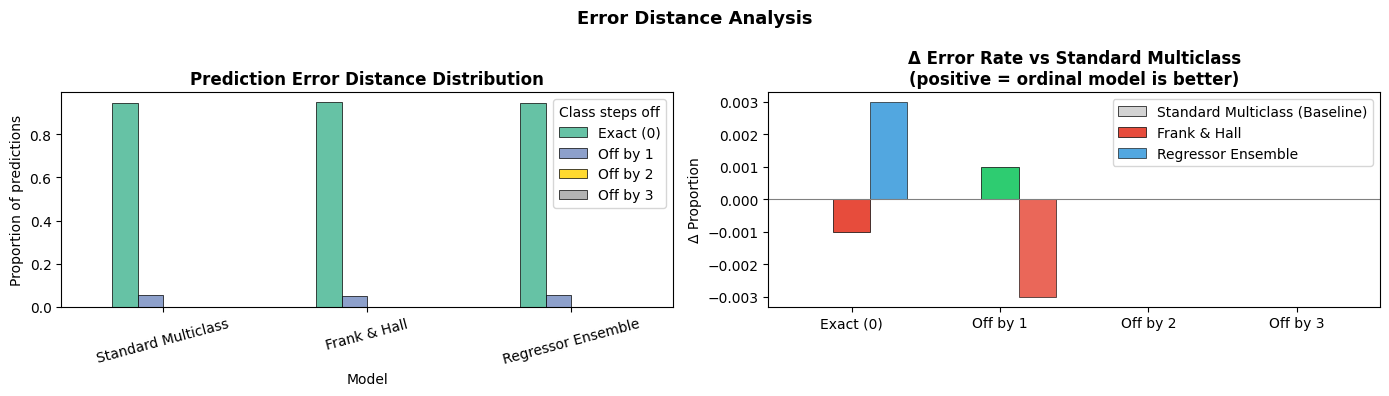

In [8]:
err_cat = np.abs(y_test - y_pred_cat)
err_fh  = np.abs(y_test - y_pred_fh)
err_reg = np.abs(y_test - y_pred_reg)

err_df = pd.DataFrame({
    "Standard Multiclass": np.bincount(err_cat, minlength=4) / len(y_test),
    "Frank & Hall":        np.bincount(err_fh,  minlength=4) / len(y_test),
    "Regressor Ensemble":  np.bincount(err_reg, minlength=4) / len(y_test),
}, index=["Exact (0)", "Off by 1", "Off by 2", "Off by 3"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

err_df.T.plot(kind="bar", ax=axes[0], colormap="Set2",
            edgecolor="black", linewidth=0.5)
axes[0].set_title("Prediction Error Distance Distribution", fontweight="bold")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Proportion of predictions")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(title="Class steps off")

# Delta vs Standard
delta_std = err_df["Standard Multiclass"] - err_df["Standard Multiclass"]
delta_fh  = err_df["Standard Multiclass"] - err_df["Frank & Hall"]
delta_reg = err_df["Standard Multiclass"] - err_df["Regressor Ensemble"]

x         = np.arange(len(err_df))
width     = 0.25

# 1. Standard Multiclass (Baseline)
axes[1].bar(x - width, delta_std, width, label="Standard Multiclass (Baseline)",
            color="lightgray", edgecolor="black", linewidth=0.5)

# 2. Frank & Hall
axes[1].bar(x, delta_fh, width, label="Frank & Hall",
            color=["#2ecc71" if v >= 0 else "#e74c3c" for v in delta_fh],
            edgecolor="black", linewidth=0.5)

# 3. Regressor Ensemble
axes[1].bar(x + width, delta_reg, width, label="Regressor Ensemble",
            color=["#3498db" if v >= 0 else "#e74c3c" for v in delta_reg],
            edgecolor="black", linewidth=0.5, alpha=0.85)

axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(err_df.index)
axes[1].set_title("Δ Error Rate vs Standard Multiclass\n(positive = ordinal model is better)",
                fontweight="bold")
axes[1].set_ylabel("Δ Proportion")
axes[1].legend()

plt.suptitle("Error Distance Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

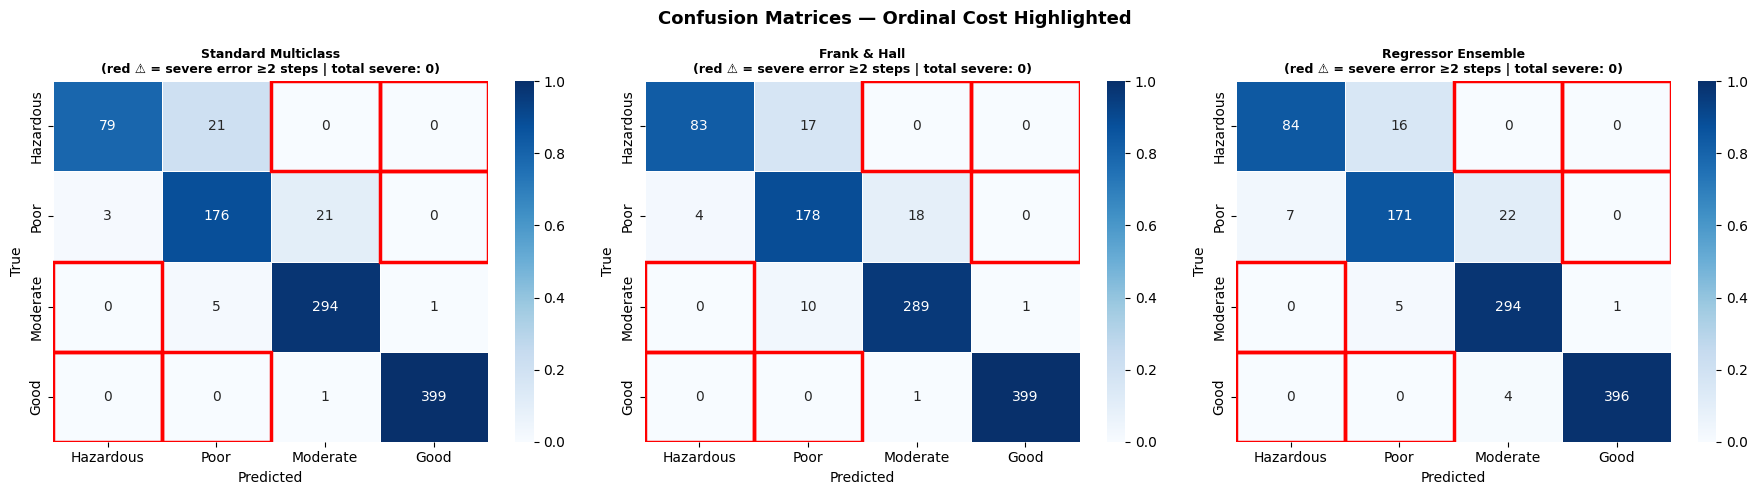

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_cat, "Standard Multiclass"),
    (y_pred_fh,  "Frank & Hall"),
    (y_pred_reg, "Regressor Ensemble"),
]):
    cm      = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, ax=ax, annot=cm, fmt="d",
        cmap="Blues", linewidths=0.5,
        xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
        vmin=0, vmax=1,
    )

    for i in range(4):
        for j in range(4):
            dist = abs(i - j)
            if dist >= 2:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=False, edgecolor="red", linewidth=2.5, zorder=3
                ))
                if cm[i, j] > 0:
                    ax.text(j + 0.5, i + 0.85, "⚠",
                            ha="center", fontsize=10, color="red", zorder=4)

    # Severe error count summary
    severe = sum(cm[i, j] for i in range(4) for j in range(4) if abs(i-j) >= 2)
    ax.set_title(
        f"{title}\n(red ⚠ = severe error ≥2 steps | total severe: {severe})",
        fontweight="bold", fontsize=9
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices — Ordinal Cost Highlighted", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Results Summary

### What the metrics tell us

The comparison uses both **standard metrics** (Accuracy, F1, MCC) and **ordinal-aware metrics** that measure the *magnitude* of errors, not just whether a prediction is right or wrong.

The key metrics to focus on are:
- **QWK** — the primary ordinal metric; higher means errors are concentrated near the diagonal
- **MAE (class steps)** — lower is better; tells you on average how many steps away predictions land
- **Severe Error Rate** — the most safety-critical metric; a `Good` predicted as `Hazardous` is a qualitatively different failure from a `Good` predicted as `Moderate`
- **Adjacent Accuracy** — a lenient ordinal alternative to accuracy; a prediction that is off by one class still scores

### Frank & Hall — key consideration
The **monotonicity violation rate** measures how often the raw binary classifiers produce inconsistent probabilities (`P(y>1) > P(y>0)`), which violates the ordinal assumption the method is built on. A high violation rate indicates the data does not naturally satisfy the ordinal decomposition — the enforcement step corrects predictions numerically, but it signals a structural limitation of the approach on this dataset.

### Regressor Ensemble — key advantage
Unlike Frank & Hall, the regressor does not assume any particular ordinal decomposition. It learns a continuous score directly and the **Optuna-tuned thresholds** optimise the mapping back to class labels end-to-end. This makes it the most flexible of the three approaches and the most aligned with the true ordinal nature of the target.

### Conclusion
If ordinal methods produce higher QWK and lower Severe Error Rate — even with similar overall accuracy — it confirms that exploiting label order yields **safer** predictions, which in an air quality context is the more meaningful outcome.

In [10]:
data = pd.read_csv("../data/updated_pollution_dataset.csv")
target_col  = data.columns[-1]
quality_map = {"Good": 3, "Moderate": 2, "Poor": 1, "Hazardous": 0}
data[target_col] = data[target_col].map(quality_map).astype("int8")

feature_cols = [col for col in data.columns if col != target_col]
X = data[feature_cols].values
y = data[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class distribution (train): { {LABEL_MAP[k]: v for k, v in zip(*np.unique(y_train, return_counts=True))} }")

Train: (4000, 9)  |  Test: (1000, 9)
Class distribution (train): {'Hazardous': np.int64(400), 'Poor': np.int64(800), 'Moderate': np.int64(1200), 'Good': np.int64(1600)}


In [ ]:
# Noise levels
# 0.0 → original clean data
# 1.0 → light overlap
# 1.5 → moderate overlap
# 3.0 → heavy overlap

# noise=0.0 already computed in Part 1
NOISE_LEVELS = [0.0, 1.0, 1.5, 3.0]
NOISE_LEVELS_TO_RUN = [1.0, 1.5, 3.0]

X_clean = X.copy()
y_clean = y.copy()

# Seed all_results with the Part 1 results at noise=0.0
metrics_cat_0 = {**metrics_cat, "noise": 0.0}
metrics_fh_0  = {**metrics_fh,  "noise": 0.0}
metrics_reg_0 = {**metrics_reg, "noise": 0.0}

all_results = [metrics_cat_0, metrics_fh_0, metrics_reg_0]

In [12]:
def prepare_data_with_noise(X_base, y_base, noise_level, random_state=RANDOM_STATE):
    """
    Adds Gaussian noise to the features BEFORE the split to simulate
    overlap between adjacent classes (Good/Moderate, Poor/Hazardous).

    Noise is applied with a different seed than RANDOM_STATE so it remains
    independent from the split — keeping both sources of randomness separate.
    """
    if noise_level > 0:
        rng     = np.random.default_rng(random_state + int(noise_level * 100))
        X_noisy = X_base + rng.normal(0, noise_level, X_base.shape)
    else:
        X_noisy = X_base.copy()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_noisy, y_base,
        test_size=0.2,
        stratify=y_base,
        random_state=random_state
    )

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)

    return X_tr, X_te, y_tr, y_te

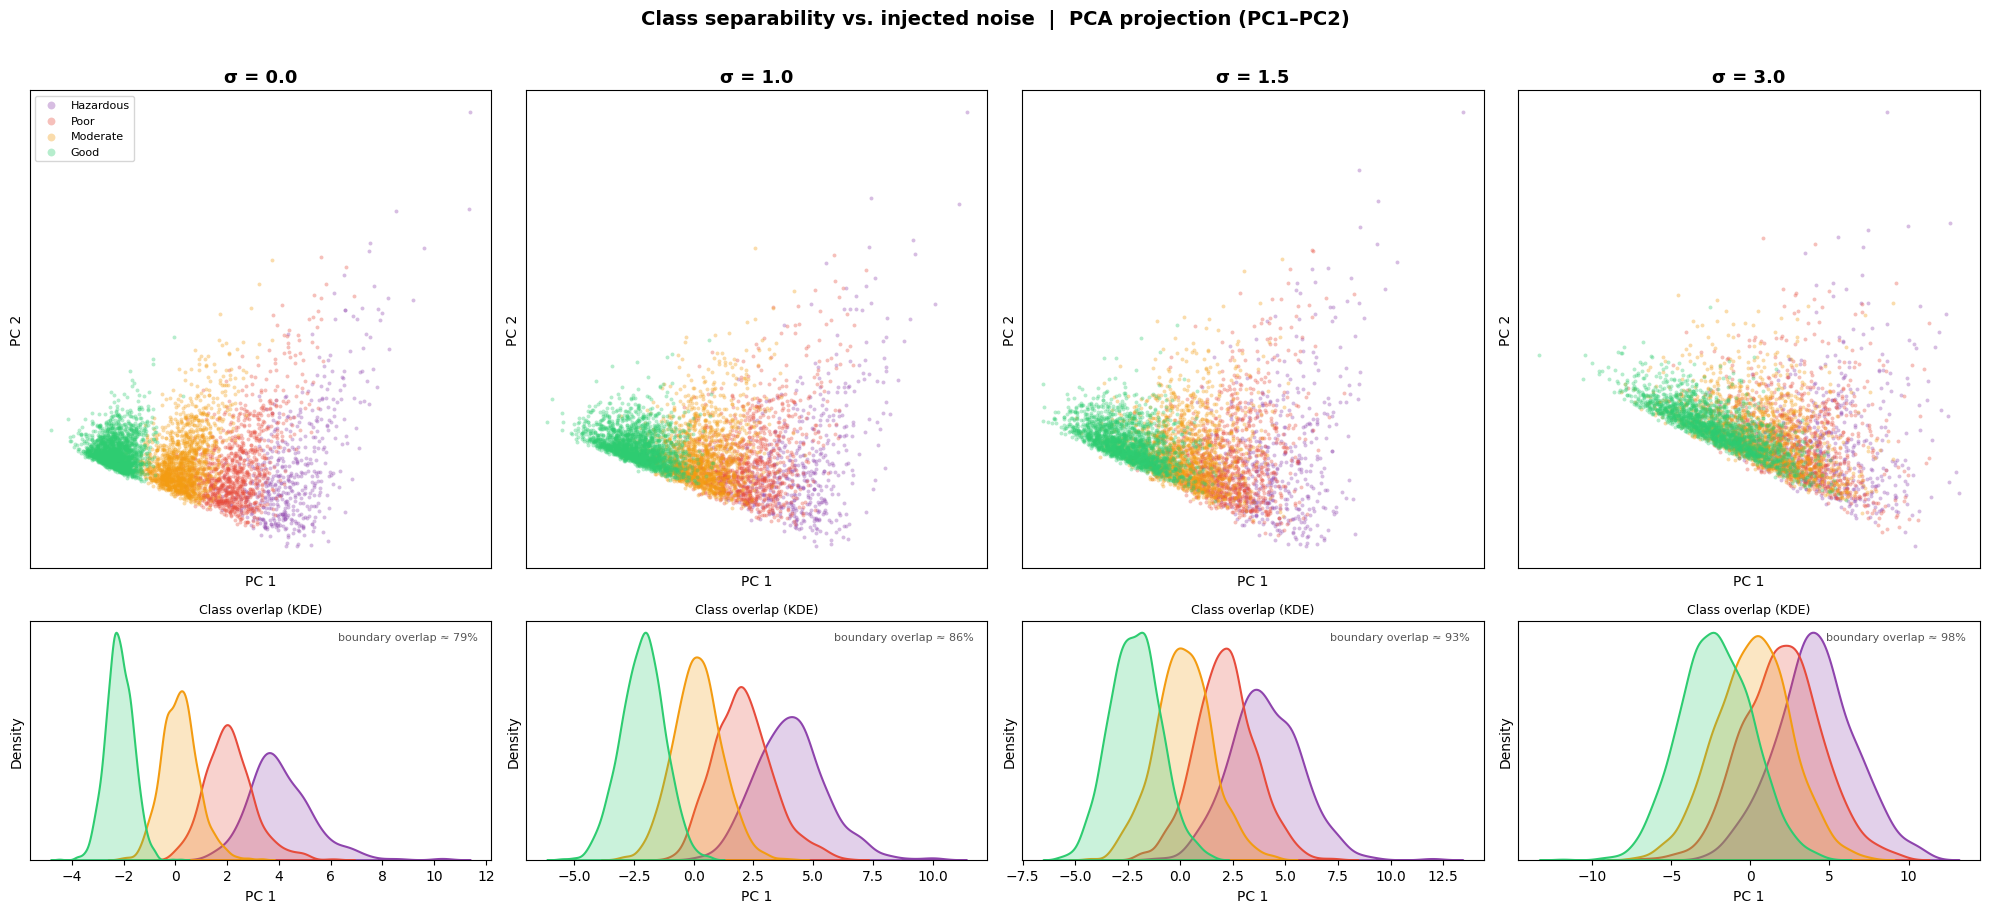

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SS

CLASS_COLORS = {0: "#8e44ad", 1: "#e74c3c", 2: "#f39c12", 3: "#2ecc71"}

# Reduce to 2D with PCA fitted on clean dataset
pca    = PCA(n_components=2, random_state=RANDOM_STATE)
scaler = SS()
X_scaled_clean = scaler.fit_transform(X_clean)
pca.fit(X_scaled_clean)

fig, axes = plt.subplots(
    2, len(NOISE_LEVELS),
    figsize=(5 * len(NOISE_LEVELS), 9),
    gridspec_kw={"height_ratios": [2, 1]}
)

for col, noise in enumerate(NOISE_LEVELS):
    ax_scatter = axes[0, col]
    ax_kde     = axes[1, col]

    # Generate noisy version
    if noise > 0:
        rng     = np.random.default_rng(RANDOM_STATE + int(noise * 100))
        X_noisy = X_clean + rng.normal(0, noise, X_clean.shape)
    else:
        X_noisy = X_clean.copy()

    # Project to 2D
    X_2d = pca.transform(scaler.transform(X_noisy))

    # PCA Scatter
    for cls in [0, 1, 2, 3]:
        mask = y_clean == cls
        ax_scatter.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=CLASS_COLORS[cls], label=LABEL_MAP[cls],
            alpha=0.35, s=8, linewidths=0
        )

    ax_scatter.set_title(f"σ = {noise}", fontsize=13, fontweight="bold")
    ax_scatter.set_xlabel("PC 1"); ax_scatter.set_ylabel("PC 2")
    if col == 0:
        ax_scatter.legend(markerscale=2, fontsize=8)
    ax_scatter.set_xticks([]); ax_scatter.set_yticks([])

    # Row 2: KDE over PC1
    for cls in [0, 1, 2, 3]:
        mask = y_clean == cls
        sns.kdeplot(
            X_2d[mask, 0],
            ax=ax_kde,
            color=CLASS_COLORS[cls],
            fill=True, alpha=0.25,
            linewidth=1.5,
            label=LABEL_MAP[cls]
        )

    ax_kde.set_xlabel("PC 1"); ax_kde.set_ylabel("Density")
    ax_kde.set_title("Class overlap (KDE)", fontsize=9)
    ax_kde.set_yticks([])

    vals    = [X_2d[y_clean == c, 0] for c in [0, 1, 2, 3]]
    overlap = sum(
        np.mean((vals[i] >= vals[i+1].min()) & (vals[i] <= vals[i+1].max()))
        for i in range(3)
    ) / 3
    ax_kde.annotate(
        f"boundary overlap ≈ {overlap:.0%}",
        xy=(0.97, 0.92), xycoords="axes fraction",
        ha="right", fontsize=8,
        color="#555"
    )

fig.suptitle(
    "Class separability vs. injected noise  |  PCA projection (PC1–PC2)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

In [14]:
metrics_cat_0 = {**metrics_cat, "noise": 0.0}
metrics_fh_0  = {**metrics_fh,  "noise": 0.0}
metrics_reg_0 = {**metrics_reg, "noise": 0.0}

all_results = [metrics_cat_0, metrics_fh_0, metrics_reg_0] 

for noise in NOISE_LEVELS_TO_RUN:
    X_train_n, X_test_n, y_train_n, y_test_n = prepare_data_with_noise(X_clean, y_clean, noise)

    # Standard Multiclass
    def objective_cat(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
            "use_label_encoder": False,
            "eval_metric":       "mlogloss",
            "random_state":      RANDOM_STATE,
            "n_jobs":            -1,
        }
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        f1 = cross_val_score(
            XGBClassifier(**params), X_train_n, y_train_n,
            cv=cv, scoring="f1_macro", n_jobs=-1
        ).mean()
        trial.report(f1, step=0)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        return f1

    study_cat = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    )
    study_cat.optimize(objective_cat, n_trials=40, show_progress_bar=True)

    best_params_cat = study_cat.best_params
    best_params_cat.update({"use_label_encoder": False, "eval_metric": "mlogloss",
                            "random_state": RANDOM_STATE, "n_jobs": -1})
    print(f"\n[noise={noise}] Best CV Macro F1 (categorical): {study_cat.best_value:.4f}")

    cat_model = XGBClassifier(**best_params_cat)
    cat_model.fit(X_train_n, y_train_n)
    y_pred_cat = cat_model.predict(X_test_n)

    metrics_cat = evaluate(y_test_n, y_pred_cat, "Standard Multiclass (XGBoost)")
    metrics_cat["noise"] = noise
    all_results.append(metrics_cat)

    # Frank & Hall
    def objective_fh(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "use_label_encoder": False,
            "eval_metric":       "logloss",
            "random_state":      RANDOM_STATE,
            "n_jobs":            -1,
        }
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        qwk_scores = []
        for train_idx, val_idx in cv.split(X_train_n, y_train_n):
            X_tr, X_val = X_train_n[train_idx], X_train_n[val_idx]
            y_tr, y_val = y_train_n[train_idx], y_train_n[val_idx]
            p_gt = {}
            for t in [0, 1, 2]:
                clf = XGBClassifier(**params)
                clf.fit(X_tr, (y_tr > t).astype(int))
                p_gt[t] = clf.predict_proba(X_val)[:, 1]
            p0 = p_gt[0]
            p1 = np.minimum(p_gt[1], p0)
            p2 = np.minimum(p_gt[2], p1)
            proba = np.column_stack([1 - p0, p0 - p1, p1 - p2, p2])
            proba = np.clip(proba, 0, None)
            proba /= proba.sum(axis=1, keepdims=True)
            y_pred_fold = np.argmax(proba, axis=1)
            qwk_scores.append(cohen_kappa_score(y_val, y_pred_fold, weights="quadratic"))
        qwk = np.mean(qwk_scores)
        trial.report(qwk, step=0)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        return qwk

    study_fh = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    )
    study_fh.optimize(objective_fh, n_trials=40, show_progress_bar=True)

    best_params_fh = study_fh.best_params
    best_params_fh.update({"use_label_encoder": False, "eval_metric": "logloss",
                            "random_state": RANDOM_STATE, "n_jobs": -1})
    print(f"\n[noise={noise}] Best CV QWK (Frank & Hall): {study_fh.best_value:.4f}")

    bin_models = {}
    for t in [0, 1, 2]:
        clf = XGBClassifier(**best_params_fh)
        clf.fit(X_train_n, (y_train_n > t).astype(int))
        bin_models[t] = clf

    p_gt = {t: bin_models[t].predict_proba(X_test_n)[:, 1] for t in [0, 1, 2]}
    p0 = p_gt[0]
    p1 = np.minimum(p_gt[1], p0)
    p2 = np.minimum(p_gt[2], p1)
    proba_ord = np.column_stack([1 - p0, p0 - p1, p1 - p2, p2])
    proba_ord = np.clip(proba_ord, 0, None)
    proba_ord /= proba_ord.sum(axis=1, keepdims=True)
    y_pred_fh = np.argmax(proba_ord, axis=1)

    metrics_fh = evaluate(y_test_n, y_pred_fh, "Ordinal — Frank & Hall")
    metrics_fh["noise"] = noise
    all_results.append(metrics_fh)

    # Regressor Ensemble
    def objective_reg(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "random_state":      RANDOM_STATE,
            "n_jobs":            -1,
        }
        t1 = trial.suggest_float("t1", 0.3, 1.2)
        t2 = trial.suggest_float("t2", 1.2, 2.2)
        t3 = trial.suggest_float("t3", 2.2, 3.0)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        qwk_scores = []
        for train_idx, val_idx in cv.split(X_train_n, y_train_n):
            X_tr, X_val = X_train_n[train_idx], X_train_n[val_idx]
            y_tr, y_val = y_train_n[train_idx], y_train_n[val_idx]
            reg = XGBRegressor(**params)
            reg.fit(X_tr, y_tr)
            preds_raw = reg.predict(X_val)
            preds     = np.digitize(preds_raw, bins=[t1, t2, t3])
            qwk_scores.append(cohen_kappa_score(y_val, preds, weights="quadratic"))
        qwk = np.mean(qwk_scores)
        trial.report(qwk, step=0)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        return qwk

    study_reg = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    )
    study_reg.optimize(objective_reg, n_trials=50, show_progress_bar=True)

    best = study_reg.best_params
    print(f"\n[noise={noise}] Best CV QWK (Regressor): {study_reg.best_value:.4f}")
    print(f"Optimal thresholds — t1={best['t1']:.3f}, t2={best['t2']:.3f}, t3={best['t3']:.3f}")

    reg_params = {k: v for k, v in best.items() if k not in ["t1", "t2", "t3"]}
    reg_params.update({"random_state": RANDOM_STATE, "n_jobs": -1})

    reg_model  = XGBRegressor(**reg_params)
    reg_model.fit(X_train_n, y_train_n)
    preds_raw  = reg_model.predict(X_test_n)
    y_pred_reg = np.digitize(preds_raw, bins=[best["t1"], best["t2"], best["t3"]])

    metrics_reg = evaluate(y_test_n, y_pred_reg, "Ordinal — Regressor Ensemble")
    metrics_reg["noise"] = noise
    all_results.append(metrics_reg)

results_noise_df = pd.DataFrame(all_results)
results_noise_df.head()

  0%|          | 0/40 [00:00<?, ?it/s]


[noise=0.0] Best CV Macro F1 (categorical): 0.9365


  0%|          | 0/40 [00:00<?, ?it/s]


[noise=0.0] Best CV QWK (Frank & Hall): 0.9792


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]


[noise=3.0] Best CV QWK (Frank & Hall): 0.9184


  0%|          | 0/50 [00:00<?, ?it/s]


[noise=3.0] Best CV QWK (Regressor): 0.9160
Optimal thresholds — t1=0.768, t2=1.519, t3=2.541


,Model,Accuracy,Macro F1,MCC,MAE (class steps),Adjacent Accuracy,Quadratic Weighted κ,Linear Weighted κ,Kendall's τ,Spearman's ρ,Severe Error Rate (≥2),Adjacent Error Rate,noise
0,Standard Multiclass (XGBoost),0.945,0.9226,0.9214,0.055,1.0,0.9717,0.9482,0.9674,0.9821,0.0,0.055,0.0
1,Ordinal — Frank & Hall,0.949,0.9266,0.9271,0.051,1.0,0.9738,0.9521,0.9704,0.9842,0.0,0.051,0.0
2,Ordinal — Regressor Ensemble,0.947,0.9197,0.9245,0.053,1.0,0.9724,0.9499,0.9705,0.9844,0.0,0.053,0.0
3,Standard Multiclass (XGBoost),0.910,0.8784,0.8711,0.090,1.0,0.9537,0.9153,0.9436,0.9662,0.0,0.090,1.0
4,Ordinal — Frank & Hall,0.915,0.8839,0.8782,0.085,1.0,0.9564,0.9202,0.9475,0.9693,0.0,0.085,1.0


In [15]:
def highlight_best(s):
    lower_is_better = {"MAE (class steps)", "Severe Error Rate (≥2)", "Adjacent Error Rate"}
    if s.name in lower_is_better:
        best = s == s.min()
    else:
        best = s == s.max()
    return ["font-weight: bold; color: green" if v else "" for v in best]

for noise in NOISE_LEVELS:
    print(f"\n{'='*55}\n  noise = {noise}\n{'='*55}")
    df_noise = (
        results_noise_df[results_noise_df["noise"] == noise]
        .set_index("Model")
        .drop(columns=["noise"])
    )
    display(df_noise.T.style.apply(highlight_best, axis=1))


  noise = 0.0


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.945000,0.949000,0.947000
Macro F1,0.922600,0.926600,0.919700
MCC,0.921400,0.927100,0.924500
MAE (class steps),0.055000,0.051000,0.053000
Adjacent Accuracy,1.000000,1.000000,1.000000
Quadratic Weighted κ,0.971700,0.973800,0.972400
Linear Weighted κ,0.948200,0.952100,0.949900
Kendall's τ,0.967400,0.970400,0.970500
Spearman's ρ,0.982100,0.984200,0.984400
Severe Error Rate (≥2),0.000000,0.000000,0.000000



  noise = 1.0


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.910000,0.915000,0.903000
Macro F1,0.878400,0.883900,0.865400
MCC,0.871100,0.878200,0.860800
MAE (class steps),0.090000,0.085000,0.097000
Adjacent Accuracy,1.000000,1.000000,1.000000
Quadratic Weighted κ,0.953700,0.956400,0.950300
Linear Weighted κ,0.915300,0.920200,0.908800
Kendall's τ,0.943600,0.947500,0.941000
Spearman's ρ,0.966200,0.969300,0.965200
Severe Error Rate (≥2),0.000000,0.000000,0.000000



  noise = 1.5


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.888000,0.897000,0.888000
Macro F1,0.854100,0.870400,0.859100
MCC,0.839400,0.852500,0.840300
MAE (class steps),0.113000,0.103000,0.112000
Adjacent Accuracy,0.999000,1.000000,1.000000
Quadratic Weighted κ,0.941100,0.948100,0.944800
Linear Weighted κ,0.893900,0.904100,0.897100
Kendall's τ,0.926000,0.931300,0.926900
Spearman's ρ,0.953700,0.956500,0.954600
Severe Error Rate (≥2),0.001000,0.000000,0.000000



  noise = 3.0


Model,Standard Multiclass (XGBoost),Ordinal — Frank & Hall,Ordinal — Regressor Ensemble
Accuracy,0.856000,0.851000,0.825000
Macro F1,0.826100,0.823300,0.786100
MCC,0.793400,0.786000,0.752500
MAE (class steps),0.148000,0.152000,0.179000
Adjacent Accuracy,0.996000,0.997000,0.996000
Quadratic Weighted κ,0.919700,0.918700,0.911900
Linear Weighted κ,0.860600,0.856900,0.839000
Kendall's τ,0.895000,0.891300,0.882100
Spearman's ρ,0.929000,0.926000,0.921400
Severe Error Rate (≥2),0.004000,0.003000,0.004000


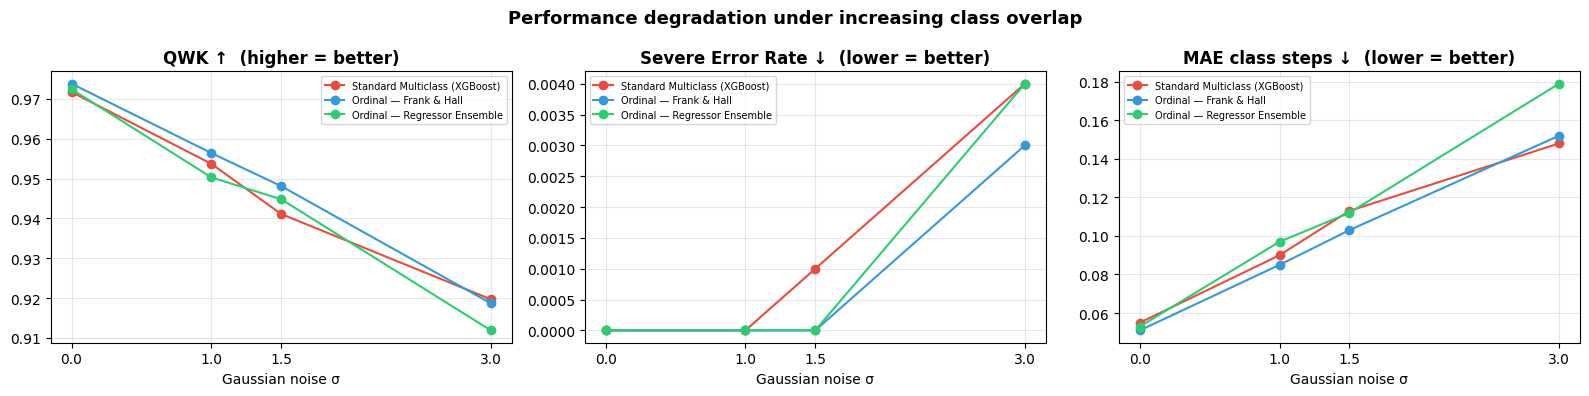

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {
    "Standard Multiclass (XGBoost)": "#e74c3c",
    "Ordinal — Frank & Hall":         "#3498db",
    "Ordinal — Regressor Ensemble":   "#2ecc71",
}

for model, c in colors.items():
    df_m = results_noise_df[results_noise_df["Model"] == model]

    axes[0].plot(df_m["noise"], df_m["Quadratic Weighted κ"],
                marker="o", label=model, color=c)
    axes[1].plot(df_m["noise"], df_m["Severe Error Rate (≥2)"],
                marker="o", label=model, color=c)
    axes[2].plot(df_m["noise"], df_m["MAE (class steps)"],
                marker="o", label=model, color=c)

titles = [
    "QWK ↑  (higher = better)",
    "Severe Error Rate ↓  (lower = better)",
    "MAE class steps ↓  (lower = better)",
]
for ax, title in zip(axes, titles):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Gaussian noise σ")
    ax.set_xticks(NOISE_LEVELS)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Performance degradation under increasing class overlap",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()